In [23]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from pathlib import Path

from sklearn.linear_model import Ridge
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline

In [24]:
PROJECT_ROOT = Path("..")

DATA_PROCESSED = PROJECT_ROOT / "data" / "processed"
DATA_LATENT = PROJECT_ROOT / "data" / "latent"
DATA_BACKTESTS = PROJECT_ROOT / "data" / "backtests"

returns = pd.read_parquet(DATA_PROCESSED / "returns.parquet")
features = pd.read_parquet(DATA_PROCESSED / "features.parquet")
vae_returns = pd.read_parquet(DATA_BACKTESTS / "vae_ridge_portfolio_returns.parquet")

returns.index = pd.to_datetime(returns.index)
features.index = pd.to_datetime(features.index)
vae_returns.index = pd.to_datetime(vae_returns.index)

vae_returns.head()

,vae_ridge_return
date,
2015-09-21,-0.002542
2015-09-22,-0.001302
2015-09-23,0.001072
2015-09-24,-0.002631
2015-09-25,-0.005256


In [25]:
def performance_stats(r):
    r = r.dropna()

    total_return = (1 + r).prod() - 1
    ann_return = (1 + total_return) ** (252 / len(r)) - 1
    ann_vol = r.std() * np.sqrt(252)
    sharpe = ann_return / ann_vol if ann_vol > 0 else np.nan

    equity = (1 + r).cumprod()
    running_max = equity.cummax()
    drawdown = equity / running_max - 1
    max_drawdown = drawdown.min()

    return pd.Series({
        "total_return": total_return,
        "ann_return": ann_return,
        "ann_vol": ann_vol,
        "sharpe": sharpe,
        "max_drawdown": max_drawdown,
    })

In [26]:
test_start = vae_returns.index[int(0.7 * len(vae_returns))]
test_end = vae_returns.index.max()

test_start, test_end

(Timestamp('2022-03-17 00:00:00'), Timestamp('2024-12-30 00:00:00'))

In [27]:
test_index = vae_returns.loc[test_start:test_end].index

In [28]:
def positions_from_scores(score_df, long_q=0.8, short_q=0.2):
    positions = pd.DataFrame(
        0,
        index=score_df.index,
        columns=score_df.columns
    )

    for date in score_df.index:
        scores = score_df.loc[date].dropna()

        if len(scores) == 0:
            continue

        long_threshold = scores.quantile(long_q)
        short_threshold = scores.quantile(short_q)

        positions.loc[date, scores.index[scores >= long_threshold]] = 1
        positions.loc[date, scores.index[scores <= short_threshold]] = -1

    return positions

In [29]:
def portfolio_returns_from_positions(positions, returns, transaction_cost=0.0):
    """
    positions at date t are applied to returns at t+1.
    """
    next_returns = returns.shift(-1)

    common_index = positions.index.intersection(next_returns.index)
    common_cols = positions.columns.intersection(next_returns.columns)

    pos = positions.loc[common_index, common_cols]
    ret = next_returns.loc[common_index, common_cols]

    gross = (pos * ret).mean(axis=1)

    turnover = pos.diff().abs().mean(axis=1).fillna(0.0)
    costs = transaction_cost * turnover

    net = gross - costs

    return net

In [30]:
flat_returns = pd.Series(
    0.0,
    index=test_index,
    name="flat"
)

In [31]:
bh_returns = returns.loc[test_index].mean(axis=1)
bh_returns.name = "buy_and_hold_equal_weight"

In [32]:
rng = np.random.default_rng(42)

random_scores = pd.DataFrame(
    rng.normal(size=returns.loc[test_index].shape),
    index=test_index,
    columns=returns.columns
)

random_positions = positions_from_scores(random_scores)

random_returns = portfolio_returns_from_positions(
    random_positions,
    returns
)

random_returns = random_returns.loc[test_index]
random_returns.name = "random_long_short"

In [33]:
momentum_60 = features.xs("momentum_60", axis=1, level="feature")

momentum_scores = momentum_60.loc[test_index]

momentum_positions = positions_from_scores(momentum_scores)

momentum_returns = portfolio_returns_from_positions(
    momentum_positions,
    returns
)

momentum_returns = momentum_returns.loc[test_index]
momentum_returns.name = "momentum_60"

In [34]:
HORIZON = 5

future_returns = returns.shift(-1).rolling(HORIZON).sum()

In [35]:
feature_names = features.columns.get_level_values("feature").unique().tolist()
tickers = features.columns.get_level_values("ticker").unique().tolist()

rows = []

for ticker in tickers:
    df_t = features[ticker].copy()
    df_t["target_return_5d"] = future_returns[ticker]
    df_t["ticker"] = ticker
    df_t["date"] = df_t.index
    rows.append(df_t)

raw_df = pd.concat(rows, axis=0).dropna()

raw_df.head()

feature,momentum_120,momentum_20,momentum_60,return_1d,volatility_20,volatility_60,target_return_5d,ticker,date
Date,,,,,,,,,
2015-06-25,0.175687,-0.032478,0.028952,-0.004762,0.006550,0.011349,0.001291,AAPL,2015-06-25
2015-06-26,0.202652,-0.027096,0.024382,-0.005882,0.006226,0.011376,-0.024202,AAPL,2015-06-26
2015-06-29,0.181477,-0.046039,-0.002153,-0.017515,0.007136,0.011558,-0.012430,AAPL,2015-06-29
2015-06-30,0.173559,-0.034857,-0.010962,0.007227,0.007425,0.011402,-0.011604,AAPL,2015-06-30
2015-07-01,0.140679,-0.027052,0.008879,0.009328,0.007807,0.011383,-0.008106,AAPL,2015-07-01


In [36]:
train_mask = raw_df["date"] < test_start
test_mask = raw_df["date"] >= test_start

X_train = raw_df.loc[train_mask, feature_names].values
y_train = raw_df.loc[train_mask, "target_return_5d"].values

X_test = raw_df.loc[test_mask, feature_names].values
y_test = raw_df.loc[test_mask, "target_return_5d"].values

In [37]:
raw_ridge = Pipeline([
    ("scaler", StandardScaler()),
    ("ridge", Ridge(alpha=10.0))
])

raw_ridge.fit(X_train, y_train)

print("Raw Ridge test corr:",
      np.corrcoef(y_test, raw_ridge.predict(X_test))[0, 1])

Raw Ridge test corr: 0.539036800559708


/Users/holloaron/vae_trading_project/venv/lib/python3.9/site-packages/sklearn/linear_model/_base.py:279: RuntimeWarning: divide by zero encountered in matmul
  return X @ coef_ + self.intercept_
/Users/holloaron/vae_trading_project/venv/lib/python3.9/site-packages/sklearn/linear_model/_base.py:279: RuntimeWarning: overflow encountered in matmul
  return X @ coef_ + self.intercept_
/Users/holloaron/vae_trading_project/venv/lib/python3.9/site-packages/sklearn/linear_model/_base.py:279: RuntimeWarning: invalid value encountered in matmul
  return X @ coef_ + self.intercept_


In [38]:
raw_df["score_raw_ridge"] = raw_ridge.predict(
    raw_df[feature_names].values
)

/Users/holloaron/vae_trading_project/venv/lib/python3.9/site-packages/sklearn/linear_model/_base.py:279: RuntimeWarning: divide by zero encountered in matmul
  return X @ coef_ + self.intercept_
/Users/holloaron/vae_trading_project/venv/lib/python3.9/site-packages/sklearn/linear_model/_base.py:279: RuntimeWarning: overflow encountered in matmul
  return X @ coef_ + self.intercept_
/Users/holloaron/vae_trading_project/venv/lib/python3.9/site-packages/sklearn/linear_model/_base.py:279: RuntimeWarning: invalid value encountered in matmul
  return X @ coef_ + self.intercept_


In [39]:
score_raw = raw_df.pivot(
    index="date",
    columns="ticker",
    values="score_raw_ridge"
)

score_raw = score_raw.loc[test_index]

raw_positions = positions_from_scores(score_raw)

raw_ridge_returns = portfolio_returns_from_positions(
    raw_positions,
    returns
)

raw_ridge_returns = raw_ridge_returns.loc[test_index]
raw_ridge_returns.name = "raw_feature_ridge"

In [40]:
vae_ridge_returns = vae_returns["vae_ridge_return"].loc[test_index]
vae_ridge_returns.name = "vae_latent_ridge"

In [41]:
all_returns = pd.concat(
    [
        flat_returns,
        bh_returns,
        random_returns,
        momentum_returns,
        raw_ridge_returns,
        vae_ridge_returns,
    ],
    axis=1
).dropna()

all_returns.head()

,flat,buy_and_hold_equal_weight,random_long_short,momentum_60,raw_feature_ridge,vae_latent_ridge
date,,,,,,
2022-03-17,0.0,0.011790,-0.000886,-0.004886,-0.000347,0.004803
2022-03-18,0.0,0.014788,0.001764,0.004314,-0.000155,0.000724
2022-03-21,0.0,-0.001102,-0.001150,-0.003472,-0.001541,0.001609
2022-03-22,0.0,0.012343,0.000118,0.006583,-0.002211,-0.003174
2022-03-23,0.0,-0.015119,0.001511,-0.002332,0.002616,0.006853


In [42]:
stats_table = all_returns.apply(performance_stats).T

stats_table.sort_values("sharpe", ascending=False)

,total_return,ann_return,ann_vol,sharpe,max_drawdown
buy_and_hold_equal_weight,0.732305,0.218379,0.184890,1.181127,-0.240011
momentum_60,0.086216,0.030176,0.057977,0.520476,-0.053471
raw_feature_ridge,0.058924,0.020795,0.052364,0.397131,-0.079120
vae_latent_ridge,0.067179,0.023649,0.059824,0.395307,-0.093070
random_long_short,0.012934,0.004631,0.033101,0.139895,-0.057048
flat,0.000000,0.000000,0.000000,NaN,0.000000


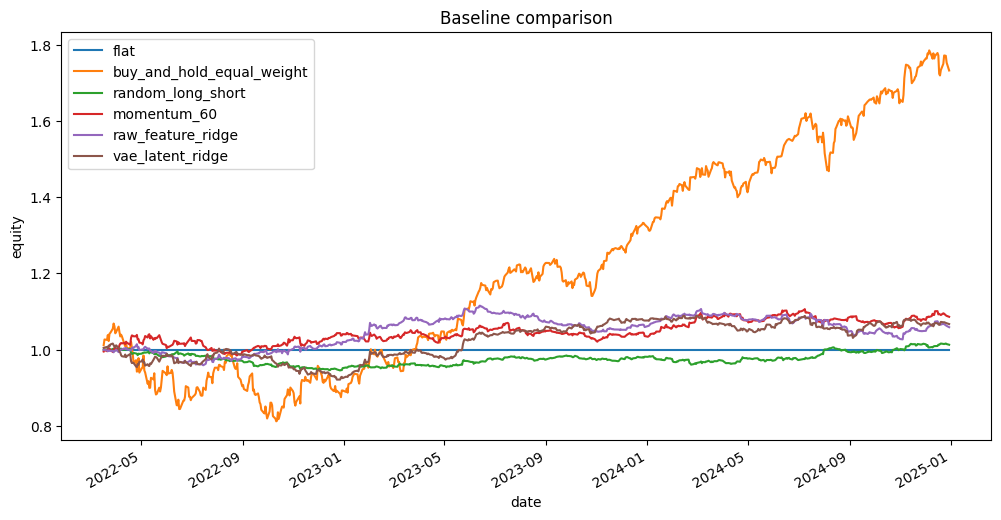

In [43]:
equity_curves = (1 + all_returns).cumprod()

equity_curves.plot(
    figsize=(12, 6),
    title="Baseline comparison"
)

plt.ylabel("equity")
plt.show()

In [22]:
all_returns.to_parquet(DATA_BACKTESTS / "baseline_comparison_returns.parquet")
stats_table.to_csv(DATA_BACKTESTS / "baseline_comparison_stats.csv")